In [2]:
# CASE 2 - VIRKNINGSGRADSANALYSE SAMKJØRT MED CASE 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prod = pd.read_excel("Sildvik_2025_produksjon_ferdig.xlsx", engine="openpyxl")
prod.columns = ["Tid_raw", "MWh"]

datetimes = []
current_date = None

for value in prod["Tid_raw"]:
    value = str(value).strip()

    if "." in value:
        parts = value.split()
        date_part = parts[0]
        hour_part = int(parts[1])
        current_date = pd.to_datetime(date_part, format="%d.%m.%y")
    else:
        hour_part = int(float(value))

    dt = current_date + pd.Timedelta(hours=hour_part - 1)
    datetimes.append(dt)

prod["Datetime"] = datetimes
prod["MWh"] = pd.to_numeric(prod["MWh"], errors="coerce")

df = prod[["Datetime", "MWh"]].dropna().reset_index(drop=True)

price = pd.read_excel("Pris_2025 (1).xlsx", engine="openpyxl")
price = price.rename(columns={
    "Dato, time": "Datetime",
    "Gjennomsnitt Pris (øre/kWh)": "Price_ore_kWh"
})

price["Datetime"] = pd.to_datetime(price["Datetime"])
price["Price_ore_kWh"] = pd.to_numeric(price["Price_ore_kWh"], errors="coerce")

# Samkjører produksjon og pris
df = pd.merge(df, price[["Datetime", "Price_ore_kWh"]], on="Datetime", how="inner")
df = df.sort_values("Datetime").reset_index(drop=True)

rho = 1000
g = 9.81
H_brutto = 655
eta_ref = 0.90
Q_max = 10.7

# MWh per time tilsvarer gjennomsnittlig MW i timen
df["P_MW"] = df["MWh"]
df["Power_W"] = df["P_MW"] * 1e6

# Beregner vannføring fra faktisk produksjon på samme måte som Case 1
df["Q_m3s"] = df["Power_W"] / (eta_ref * rho * g * H_brutto)

# Kun driftstimer brukes til selve virkningsgradsanalysen,
# men total energi og nøkkeltall hentes fra hele Case 1-datasettet.
drift = df[df["MWh"] > 0].copy()

# NB: Vi filtrerer IKKE bort timer med Q_m3s > Q_max her.
# Målet er å analysere historisk drift fra Case 1, ikke lage et nytt begrenset datasett.
# Dersom enkelte beregnede Q-verdier overstiger Q_max, beholdes de og merkes som over nominell verdi.
drift["Over_Qmax"] = drift["Q_m3s"] > Q_max

def clip_q_for_eta(Q):
    """Virkningsgradskurven er definert opp til Q_max.
    For driftspunkt over Q_max brukes Q_max i selve eta-kurven,
    slik at slike timer ikke fjernes fra energiregnskapet.
    """
    return np.minimum(np.asarray(Q, dtype=float), Q_max)

eta_max = 0.93
k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    return k_loss * Q**2

def eta_turbin(Q):
    Q_arr = np.asarray(Q, dtype=float)
    scalar = Q_arr.ndim == 0
    Q_arr = np.atleast_1d(Q_arr)

    Q_eff = clip_q_for_eta(Q_arr)
    q_rel = Q_eff / Q_max
    out = np.zeros_like(Q_eff, dtype=float)

    mask_1 = (q_rel >= 0.25) & (q_rel < 0.50)
    mask_2 = (q_rel >= 0.50) & (q_rel < 0.90)
    mask_3 = (q_rel >= 0.90) & (q_rel <= 1.00)

    out[mask_1] = 0.65 + (q_rel[mask_1] - 0.30) * (0.88 - 0.65) / 0.20
    out[mask_2] = 0.85 + 0.07 * (1 - ((q_rel[mask_2] - 0.70) / 0.20)**2)
    out[mask_3] = 0.88

    return float(out[0]) if scalar else out

def eta_category(eta):
    if eta >= 0.88:
        return "Høy virkningsgrad"
    elif eta >= 0.75:
        return "Middels virkningsgrad"
    else:
        return "Lav virkningsgrad"

# Beregner modellert virkningsgrad ved faktisk driftspunkt
drift["Q_for_eta_m3s"] = clip_q_for_eta(drift["Q_m3s"].values)
drift["q_rel"] = drift["Q_for_eta_m3s"] / Q_max
drift["eta_model"] = eta_turbin(drift["Q_m3s"].values)
drift["eta_kategori"] = drift["eta_model"].apply(eta_category)

# Falltap og netto fallhøyde
drift["h_loss_m"] = h_loss(drift["Q_for_eta_m3s"])
drift["H_netto_m"] = H_brutto - drift["h_loss_m"]

# Hydraulisk effekt tilgjengelig ved faktisk vannføring
drift["P_hyd_MW"] = rho * g * drift["Q_m3s"] * drift["H_netto_m"] / 1e6

# Modellert effekt med aktuell virkningsgrad
drift["P_model_MW"] = drift["P_hyd_MW"] * drift["eta_model"]

# Beste virkningsgrad i den forenklede kurven
Q_test = np.linspace(0, Q_max, 500)
eta_test = eta_turbin(Q_test)
eta_best = eta_test.max()

# Teoretisk effekt dersom samme vannføring kjøres med beste virkningsgrad
drift["P_best_eta_MW"] = drift["P_hyd_MW"] * eta_best

# Tapt energi per driftstime
drift["Lost_energy_MWh"] = (drift["P_best_eta_MW"] - drift["P_model_MW"]).clip(lower=0)
drift["Lost_value_NOK"] = drift["Lost_energy_MWh"] * drift["Price_ore_kWh"] * 10

total_energy_case1 = df["MWh"].sum()
total_income_case1 = (df["MWh"] * df["Price_ore_kWh"] * 1000 / 100).sum()
drift_hours_case1 = (df["MWh"] > 0).sum()
starts_case1 = ((df["MWh"] > 0) & (df["MWh"].shift(1, fill_value=0) == 0)).sum()
avg_power_when_running = drift["P_MW"].mean()

avg_eta = drift["eta_model"].mean()
weighted_eta = np.average(drift["eta_model"], weights=drift["MWh"])
hours_high_eta = (drift["eta_model"] >= 0.88).sum()
share_high_eta = hours_high_eta / len(drift) * 100
energy_high_eta = drift.loc[drift["eta_model"] >= 0.88, "MWh"].sum()
share_energy_high_eta = energy_high_eta / total_energy_case1 * 100

total_lost_energy = drift["Lost_energy_MWh"].sum()
potential_energy = total_energy_case1 + total_lost_energy
total_lost_value = drift["Lost_value_NOK"].sum()

print("=== NØKKELTALL CASE 1-GRUNNLAG ===")
print(f"Total energi: {total_energy_case1:.1f} MWh")
print(f"Total inntekt: {total_income_case1:,.0f} kr")
print(f"Driftstimer: {drift_hours_case1}")
print(f"Antall oppstarter: {starts_case1}")
print(f"Gjennomsnittlig effekt i drift: {avg_power_when_running:.2f} MW")

print("\n=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
print(f"Energivektet virkningsgrad: {weighted_eta*100:.2f} %")
print(f"Timer med høy virkningsgrad: {hours_high_eta}")
print(f"Andel driftstimer med høy virkningsgrad: {share_high_eta:.1f} %")
print(f"Andel energi produsert med høy virkningsgrad: {share_energy_high_eta:.1f} %")
print(f"Beste modellerte virkningsgrad: {eta_best*100:.2f} %")
print(f"Timer over nominell Q_max: {drift['Over_Qmax'].sum()}")

print("\n=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===")
print(f"Faktisk energi fra Case 1: {total_energy_case1:.1f} MWh")
print(f"Teoretisk energi ved beste virkningsgrad: {potential_energy:.1f} MWh")
print(f"Tapt energi pga. lavere virkningsgrad: {total_lost_energy:.1f} MWh")
print(f"Andel tapt energi: {total_lost_energy / potential_energy * 100:.2f} %")
print(f"Estimert verdi av tapt energi: {total_lost_value:,.0f} kr")

print("\nFordeling etter virkningsgrad:")
print(drift["eta_kategori"].value_counts())

=== NØKKELTALL CASE 1-GRUNNLAG ===
Total energi: 265162.1 MWh
Total inntekt: 41,662,601 kr
Driftstimer: 6225
Antall oppstarter: 65
Gjennomsnittlig effekt i drift: 42.60 MW

=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===
Gjennomsnittlig virkningsgrad i drift: 70.37 %
Energivektet virkningsgrad: 84.47 %
Timer med høy virkningsgrad: 3976
Andel driftstimer med høy virkningsgrad: 63.9 %
Andel energi produsert med høy virkningsgrad: 83.4 %
Beste modellerte virkningsgrad: 92.00 %
Timer over nominell Q_max: 1732

=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===
Faktisk energi fra Case 1: 265162.1 MWh
Teoretisk energi ved beste virkningsgrad: 287267.1 MWh
Tapt energi pga. lavere virkningsgrad: 22105.0 MWh
Andel tapt energi: 7.69 %
Estimert verdi av tapt energi: 2,279,485 kr

Fordeling etter virkningsgrad:
eta_kategori
Høy virkningsgrad        3976
Lav virkningsgrad        1514
Middels virkningsgrad     735
Name: count, dtype: int64


In [3]:
# SESONGANALYSE

def season(month):
    if month in [12, 1, 2]:
        return "Vinter"
    elif month in [3, 4, 5]:
        return "Vår"
    elif month in [6, 7, 8]:
        return "Sommer"
    else:
        return "Høst"

drift["Måned"] = drift["Datetime"].dt.month
drift["Sesong"] = drift["Måned"].apply(season)

season_summary = drift.groupby("Sesong").agg(
    Energi_MWh=("MWh", "sum"),
    Snitt_virkningsgrad=("eta_model", "mean"),
    Energivektet_virkningsgrad=("eta_model", lambda x: np.average(x, weights=drift.loc[x.index, "MWh"])),
    Tapt_energi_MWh=("Lost_energy_MWh", "sum"),
    Tapt_verdi_NOK=("Lost_value_NOK", "sum"),
    Snitt_pris_ore_kWh=("Price_ore_kWh", "mean")
)

season_summary["Snitt_virkningsgrad"] *= 100
season_summary["Energivektet_virkningsgrad"] *= 100

season_summary

,Energi_MWh,Snitt_virkningsgrad,Energivektet_virkningsgrad,Tapt_energi_MWh,Tapt_verdi_NOK,Snitt_pris_ore_kWh
Sesong,,,,,,
Høst,79122.3,71.767208,84.774048,6330.494340,922989.502132,18.359304
Sommer,38896.5,57.222637,81.117252,4695.363117,99647.406948,2.675239
Vinter,72542.8,77.525488,86.052898,4773.303941,914139.931115,19.618142
Vår,74600.5,71.350599,84.373982,6305.789377,342708.608297,6.091467


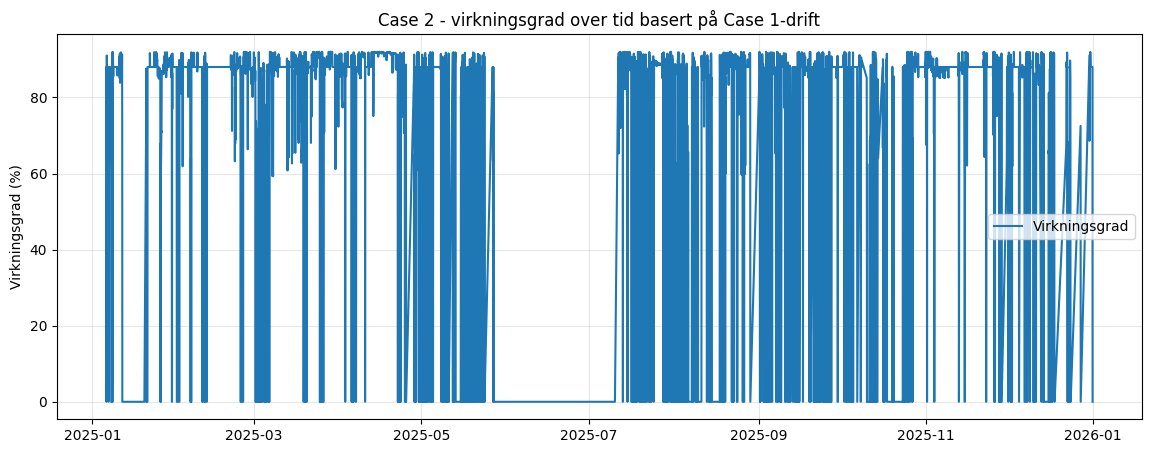

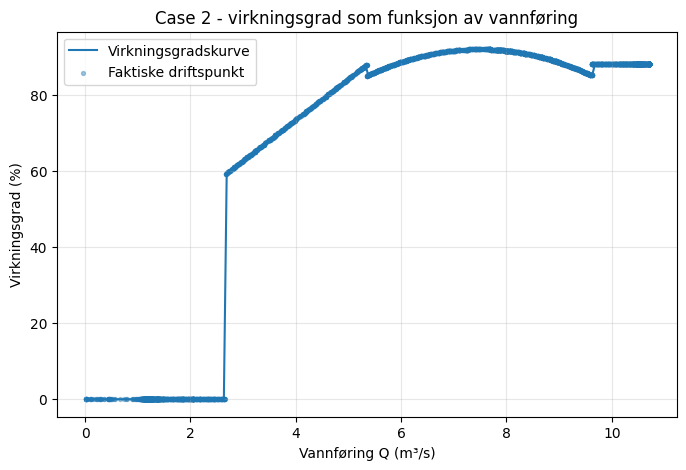

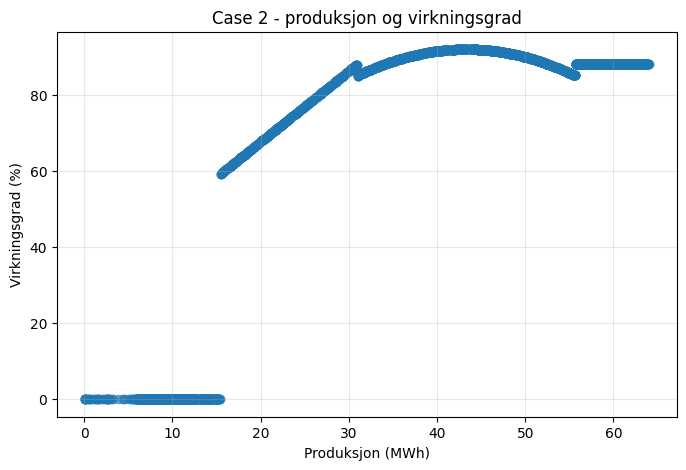

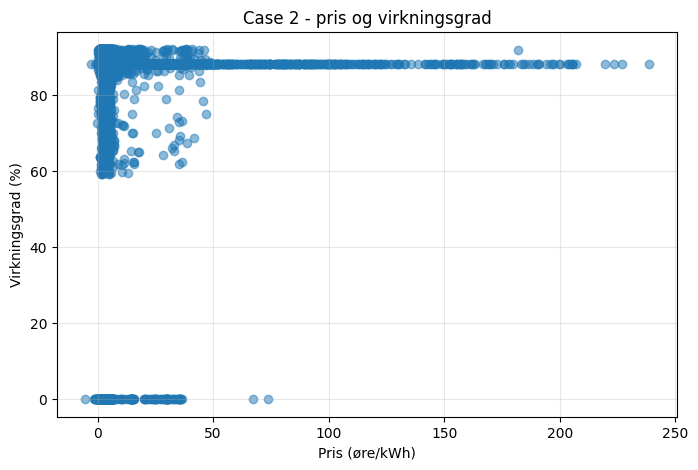

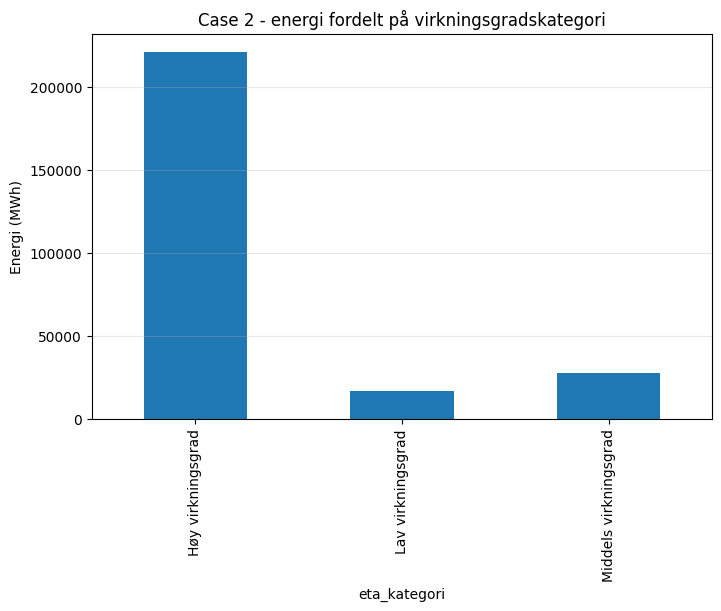

In [4]:
# PLOTS CASE 2 - VIRKNINGSGRAD

plt.figure(figsize=(14,5))
plt.plot(drift["Datetime"], drift["eta_model"] * 100, label="Virkningsgrad")
plt.title("Case 2 - virkningsgrad over tid basert på Case 1-drift")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Q_plot = np.linspace(0, Q_max, 200)
eta_plot = eta_turbin(Q_plot)

plt.figure(figsize=(8,5))
plt.plot(Q_plot, eta_plot * 100, label="Virkningsgradskurve")
plt.scatter(drift["Q_for_eta_m3s"], drift["eta_model"] * 100, s=8, alpha=0.4, label="Faktiske driftspunkt")
plt.title("Case 2 - virkningsgrad som funksjon av vannføring")
plt.xlabel("Vannføring Q (m³/s)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(drift["MWh"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - produksjon og virkningsgrad")
plt.xlabel("Produksjon (MWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(drift["Price_ore_kWh"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - pris og virkningsgrad")
plt.xlabel("Pris (øre/kWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

energy_by_eta = drift.groupby("eta_kategori")["MWh"].sum()

plt.figure(figsize=(8,5))
energy_by_eta.plot(kind="bar")
plt.title("Case 2 - energi fordelt på virkningsgradskategori")
plt.ylabel("Energi (MWh)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

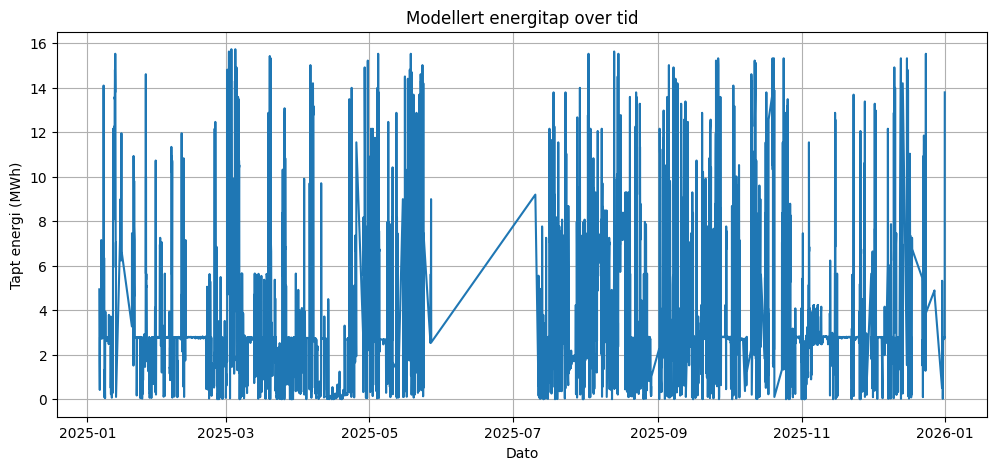

In [5]:
plt.figure(figsize=(12,5))
plt.plot(drift["Datetime"], drift["Lost_energy_MWh"])
plt.title("Modellert energitap over tid")
plt.xlabel("Dato")
plt.ylabel("Tapt energi (MWh)")
plt.grid(True)
plt.show()


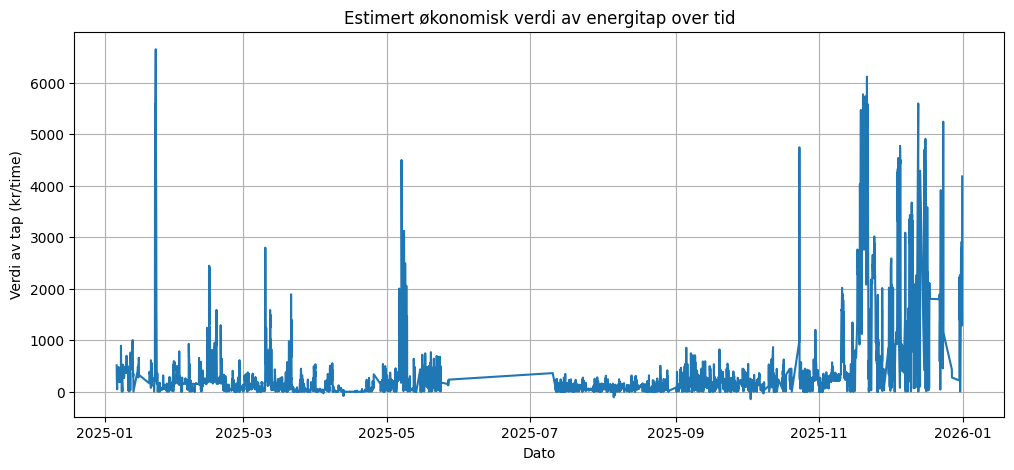

In [6]:
plt.figure(figsize=(12,5))
plt.plot(drift["Datetime"], drift["Lost_value_NOK"])
plt.title("Estimert økonomisk verdi av energitap over tid")
plt.xlabel("Dato")
plt.ylabel("Verdi av tap (kr/time)")
plt.grid(True)
plt.show()



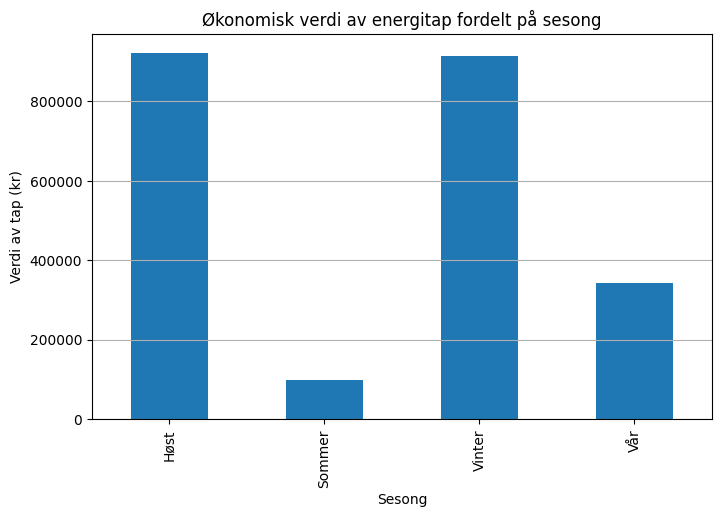

In [7]:
season_summary["Tapt_verdi_NOK"].plot(kind="bar", figsize=(8,5))
plt.title("Økonomisk verdi av energitap fordelt på sesong")
plt.ylabel("Verdi av tap (kr)")
plt.xlabel("Sesong")
plt.grid(axis="y")
plt.show()

In [8]:
# Svakheter med denne modellen:

# I praksis påvirkes total virkningsgrad også av:
#generator, transformator, hjelpesystemer, delasttap

# Virkningsgradskurven er forenklet og basert på generelle antakelser:
# Det betyr: ikke basert på faktisk hill chart, ikke levert av turbineleverandør, ikke testdata fra anlegget 

# Konstant brutto fallhøyde

# Forenklet falltap

# Modellen antar at alle nulltimer er økonomiske valg. Tar ikke hensyn til tekniske begrensninger, vedlikehold, eller andre faktorer som kan påvirke driftsbeslutninger.


# Kan forbedres ved å:
# Inkludere flere faktorer i virkningsgradskurven, som generator og transformator
# Bruke faktisk hill chart eller testdata for å kalibrere modellen
# Inkludere variasjoner i brutto fallhøyde gjennom en graf etc
